In [ ]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from collections import Counter


import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
# Read in dataset
df = pd.read_csv('WELFake_Dataset.csv').iloc[:, 1:]
df['text'] = df['text'].apply(str)
#Switch 0s and 1s
df['label'] = df['label'].apply(lambda x: 1 - x)

## EDA

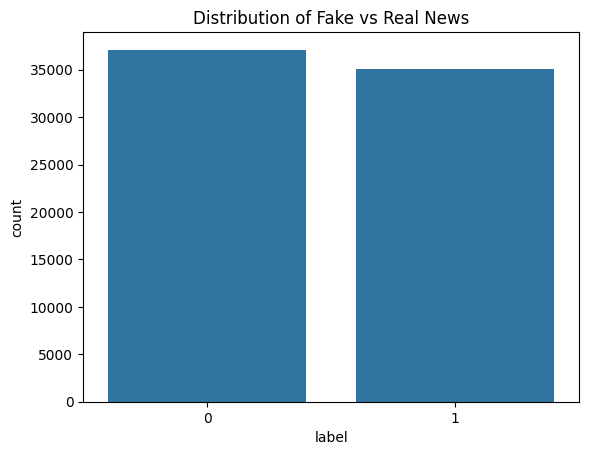

In [ ]:
# Distribution of Fake vs Real News
sns.countplot(x='label', data=df)
plt.title("Distribution of Fake vs Real News")
plt.show()

In [ ]:

#Process and clean dataframe in batches using spacy 'en_core_web_sm' model - this takes a very long time to run (overnight).
# We provided the cleaned_df as well as a csv you can read in directly in the next cell, so you can skip this cell.

"""
def process_dataframe(df):
    df = df.copy()
    df['text'] = df['text'].str.lower()
    df["clean_text"] = [
        " ".join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_digit])
        for doc in nlp.pipe(df['text'], batch_size=500, n_process=2)
    ]

    return df

cleaned_df = process_dataframe(df)
"""

In [ ]:
#Load cleaned_df to Jupyter
cleaned_df = pd.read_csv('cleaned_df.csv')
cleaned_df['text'] = cleaned_df['text'].apply(str)
cleaned_df['clean_text'] = cleaned_df['clean_text'].apply(str)

#Switch 0s and 1s in cleaned_df
cleaned_df['label'] = cleaned_df['label'].apply(lambda x: 1 - x)
cleaned_df['title_word_count'] = cleaned_df['title'].str.split().str.len()
cleaned_df['text_word_count'] = cleaned_df['text'].str.split().str.len()

In [ ]:
# Check for missing values
print(cleaned_df.isnull().sum())

title               558
text                  0
label                 0
clean_text            0
title_word_count    558
text_word_count       0
dtype: int64


In [ ]:
#Get rid of null rows for analysis

cleaned_df = cleaned_df.dropna()
cleaned_df.head()

,title,text,label,clean_text,title_word_count,text_word_count
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,no comment is expected from barack obama membe...,0,comment expect barack obama member fyf911 fuky...,18.0,871
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"now, most of the demonstrators gathered last ...",0,demonstrator gather night exercise constitut...,18.0,34
3,"Bobby Jindal, raised Hindu, uses story of Chri...",a dozen politically active pastors came here f...,1,dozen politically active pastor come private d...,16.0,1321
4,SATAN 2: Russia unvelis an image of its terrif...,"the rs-28 sarmat missile, dubbed satan 2, will...",0,rs-28 sarmat missile dub satan replace ss-18 f...,16.0,329
5,About Time! Christian Group Sues Amazon and SP...,all we can say on this one is it s about time ...,0,s time sue southern poverty law center!on tues...,13.0,244


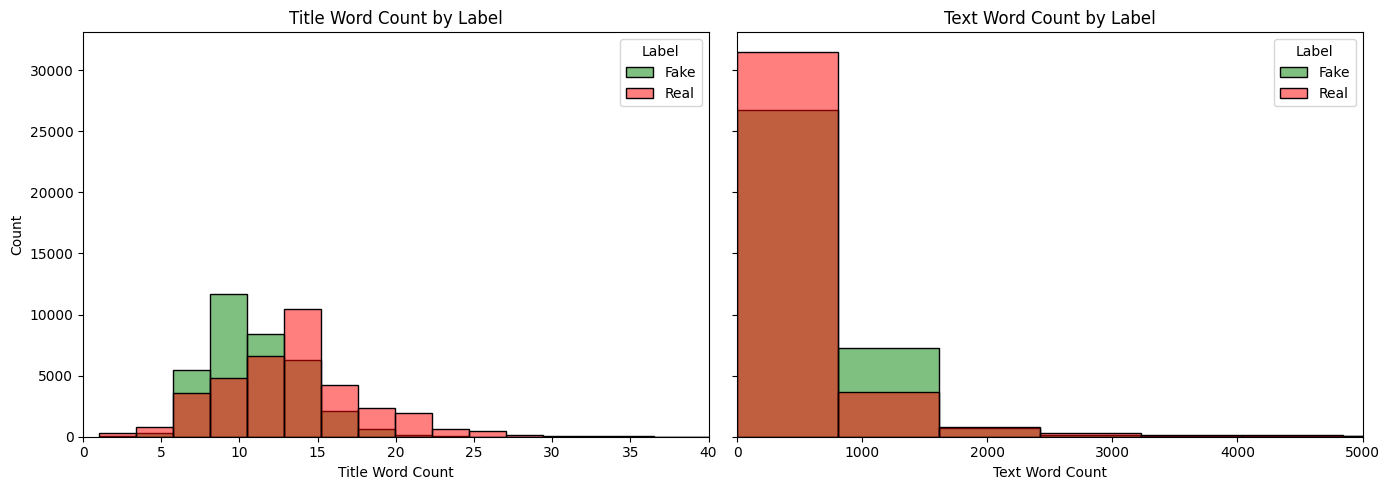

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(data=cleaned_df, x="title_word_count", hue="label", bins=30,
             palette=["red", "green"], ax=axes[0], kde=False)
axes[0].set_title("Title Word Count by Label")
axes[0].set_xlabel("Title Word Count")
axes[0].set_xlim(0, 40)
axes[0].legend(title="Label", labels=["Fake", "Real"])

sns.histplot(data=cleaned_df, x="text_word_count", hue="label", bins=30,
             palette=["red", "green"], ax=axes[1], kde=False)
axes[1].set_title("Text Word Count by Label")
axes[1].set_xlabel("Text Word Count")
axes[1].set_xlim(0, 5000)
axes[1].legend(title="Label", labels=["Fake", "Real"])

plt.tight_layout()
plt.show()

In [ ]:
# Count number of all-caps words in a title
def count_all_caps(title):
    words = title.split()
    return sum(1 for word in words if word.isupper())

# Apply function to create a new column
cleaned_df["title_all_caps_count"] = cleaned_df["title"].apply(count_all_caps)

cleaned_df.head(20)

,title,text,label,clean_text,title_word_count,text_word_count,title_all_caps_count
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,no comment is expected from barack obama membe...,0,comment expect barack obama member fyf911 fuky...,18.0,871,7
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"now, most of the demonstrators gathered last ...",0,demonstrator gather night exercise constitut...,18.0,34,11
3,"Bobby Jindal, raised Hindu, uses story of Chri...",a dozen politically active pastors came here f...,1,dozen politically active pastor come private d...,16.0,1321,0
4,SATAN 2: Russia unvelis an image of its terrif...,"the rs-28 sarmat missile, dubbed satan 2, will...",0,rs-28 sarmat missile dub satan replace ss-18 f...,16.0,329,2
5,About Time! Christian Group Sues Amazon and SP...,all we can say on this one is it s about time ...,0,s time sue southern poverty law center!on tues...,13.0,244,1
6,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,dr. ben carson tells the story of what happene...,0,dr ben carson tell story happen speak obama,20.0,15,9
7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,0,,12.0,0,3
8,Sports Bar Owner Bans NFL Games…Will Show Only...,"the owner of the ringling bar, located south o...",0,owner ringling bar locate south white sulphur ...,19.0,265,1
9,Latest Pipeline Leak Underscores Dangers Of Da...,"file – in this sept. 15, 2005 file photo, the ...",0,file sept file photo marker welcome commuter c...,9.0,485,0
10,GOP Senator Just Smacked Down The Most Puncha...,the most punchable alt-right nazi on the inter...,0,punchable alt right nazi internet get thorough...,13.0,690,1


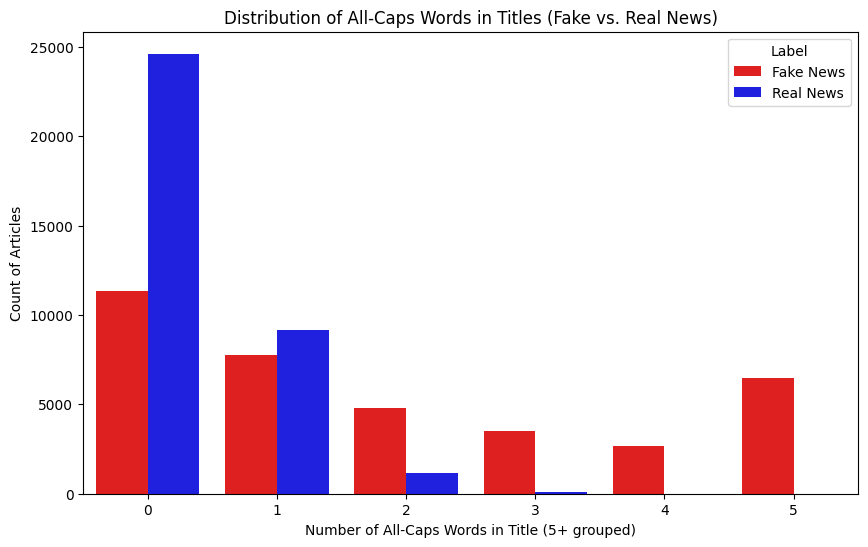

In [ ]:
# Group counts for 5 or more all-caps words into a single category
cleaned_df["title_all_caps_binned"] = cleaned_df["title_all_caps_count"].apply(lambda x: x if x < 5 else 5)

plt.figure(figsize=(10, 6))
sns.countplot(data=cleaned_df, x="title_all_caps_binned", hue="label", palette={0: "red", 1: "blue"})

plt.xlabel("Number of All-Caps Words in Title (5+ grouped)")
plt.ylabel("Count of Articles")
plt.title("Distribution of All-Caps Words in Titles (Fake vs. Real News)")
plt.legend(["Fake News", "Real News"], title="Label")

plt.show()

In [ ]:
# Add columns for presence of ! or ?
cleaned_df["has_exclamation"] = cleaned_df["title"].str.contains("!", regex=False).astype(int)
cleaned_df["has_question"] = cleaned_df["title"].str.contains("\?", regex=True).astype(int)

cleaned_df.head()

,title,text,label,clean_text,title_word_count,text_word_count,title_all_caps_count,title_all_caps_binned,has_exclamation,has_question
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,no comment is expected from barack obama membe...,0,comment expect barack obama member fyf911 fuky...,18.0,871,7,5,0,0
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"now, most of the demonstrators gathered last ...",0,demonstrator gather night exercise constitut...,18.0,34,11,5,1,0
3,"Bobby Jindal, raised Hindu, uses story of Chri...",a dozen politically active pastors came here f...,1,dozen politically active pastor come private d...,16.0,1321,0,0,0,0
4,SATAN 2: Russia unvelis an image of its terrif...,"the rs-28 sarmat missile, dubbed satan 2, will...",0,rs-28 sarmat missile dub satan replace ss-18 f...,16.0,329,2,2,0,0
5,About Time! Christian Group Sues Amazon and SP...,all we can say on this one is it s about time ...,0,s time sue southern poverty law center!on tues...,13.0,244,1,1,1,0


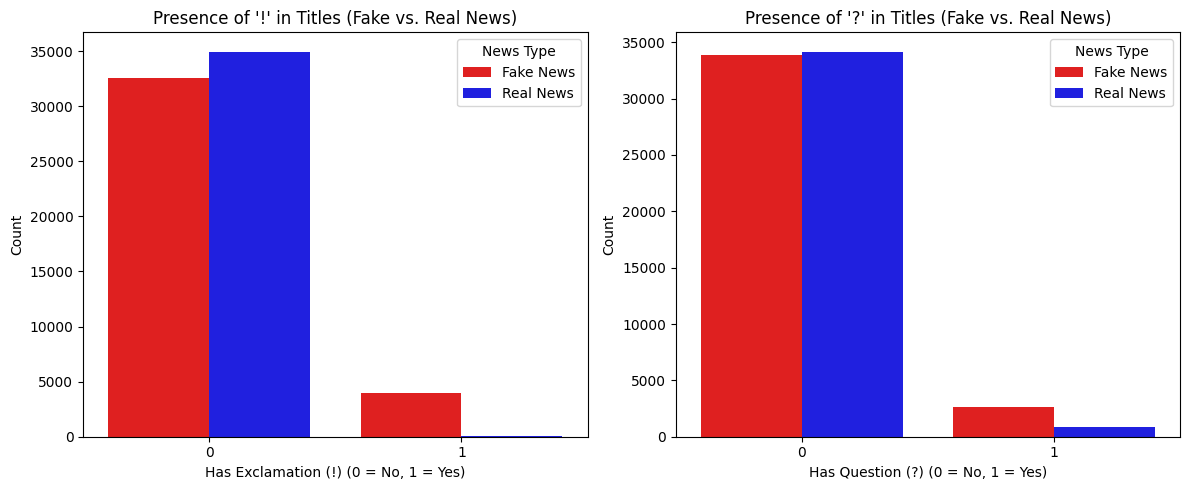

In [ ]:
#Chart to compare prescence of punctuation between fake and real news

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

legend_labels = {0: "Fake News", 1: "Real News"}

sns.countplot(data=cleaned_df, x="has_exclamation", hue="label", palette={0: "red", 1: "blue"}, ax=axes[0])
axes[0].set_title("Presence of '!' in Titles (Fake vs. Real News)")
axes[0].set_xlabel("Has Exclamation (!) (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")

sns.countplot(data=cleaned_df, x="has_question", hue="label", palette={0: "red", 1: "blue"}, ax=axes[1])
axes[1].set_title("Presence of '?' in Titles (Fake vs. Real News)")
axes[1].set_xlabel("Has Question (?) (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ["Fake News", "Real News"], title="News Type")

plt.tight_layout()
plt.show()

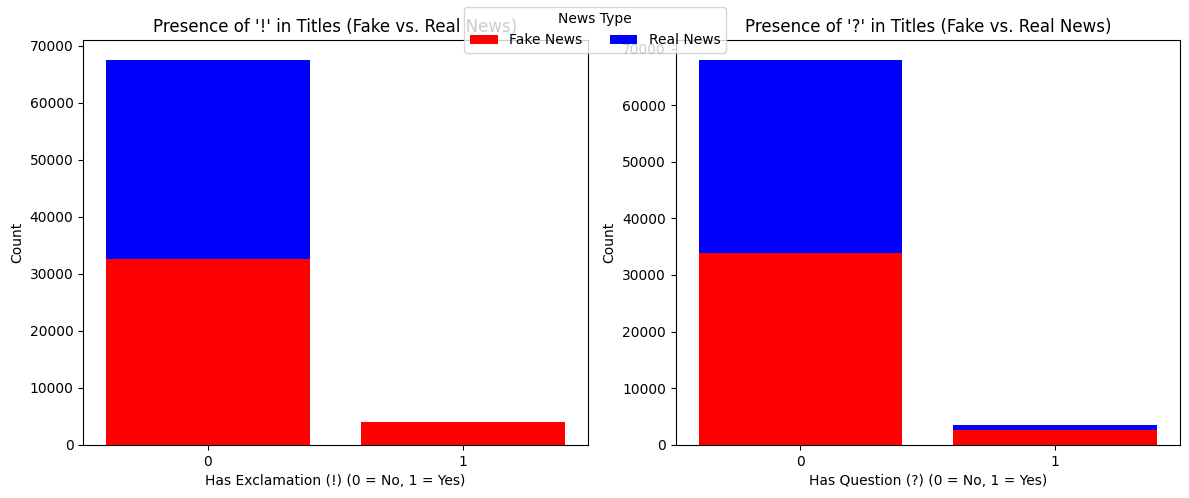

In [ ]:
#Stacked bar chart to analyze proportion of exclamation and question marks between real and fake news

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

legend_labels = {0: "Fake News", 1: "Real News"}

exclamation_counts = cleaned_df.groupby(["has_exclamation", "label"]).size().unstack()
question_counts = cleaned_df.groupby(["has_question", "label"]).size().unstack()

x1 = exclamation_counts.index
x2 = question_counts.index

axes[0].bar(x1, exclamation_counts[0], color="red", label="Fake News")
axes[0].bar(x1, exclamation_counts[1], color="blue", label="Real News", bottom=exclamation_counts[0])
axes[0].set_title("Presence of '!' in Titles (Fake vs. Real News)")
axes[0].set_xlabel("Has Exclamation (!) (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(x1)

axes[1].bar(x2, question_counts[0], color="red", label="Fake News")
axes[1].bar(x2, question_counts[1], color="blue", label="Real News", bottom=question_counts[0])
axes[1].set_title("Presence of '?' in Titles (Fake vs. Real News)")
axes[1].set_xlabel("Has Question (?) (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(x2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="News Type", loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
# Sentient analysis for text and titles - this cell takes ~2 minutes to run.

# Initialize VADER for sentient analysis
analyzer = SentimentIntensityAnalyzer()

# Function to analyze sentiment using VADER for short text like the title column
def vader_sentiment(text):
    sentiment = analyzer.polarity_scores(str(text))
    return sentiment['compound']

# Function to analyze sentiment using TextBlob for longer text like the text column
def textblob_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

# Score between -1 (negative) and 1 (positive)

cleaned_df["title_sentiment_vader"] = cleaned_df["title"].apply(vader_sentiment)


cleaned_df["text_sentiment_textblob"] = cleaned_df["clean_text"].apply(textblob_sentiment)

In [ ]:
#Labeling title sentient based on sentient scores

cleaned_df["title_sentiment_category"] = cleaned_df["title_sentiment_vader"].apply(
    lambda x: "Positive" if x > 0.05 else "Negative" if x < -0.05 else "Neutral"
)

cleaned_df["title_sentiment_category"].value_counts()

,count
title_sentiment_category,
Negative,30224
Neutral,23613
Positive,17739


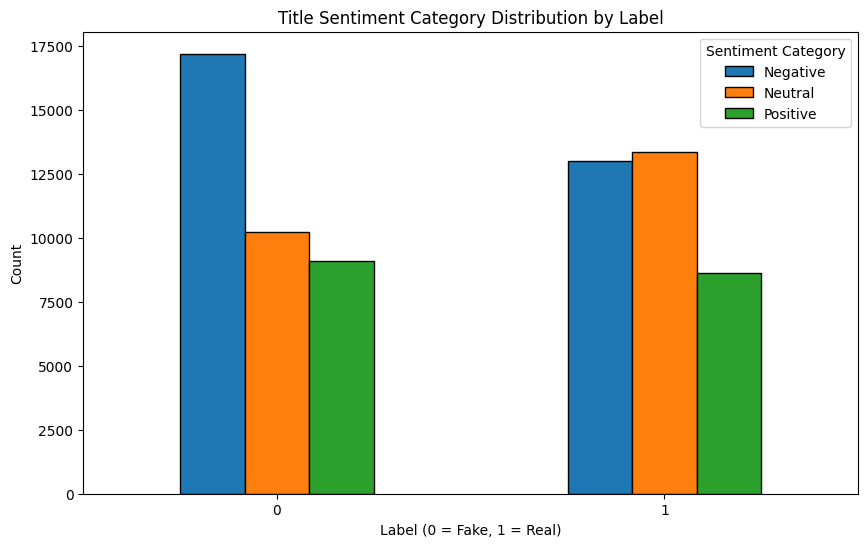

In [ ]:
#Compare distribution of sentient between fake and real news with a bar chart

sentiment_counts = cleaned_df.groupby("label")["title_sentiment_category"].value_counts().unstack()

sentiment_counts.plot(kind="bar", figsize=(10,6), edgecolor="black")

plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Count")
plt.title("Title Sentiment Category Distribution by Label")
plt.xticks(rotation=0)
plt.legend(title="Sentiment Category")

plt.show()

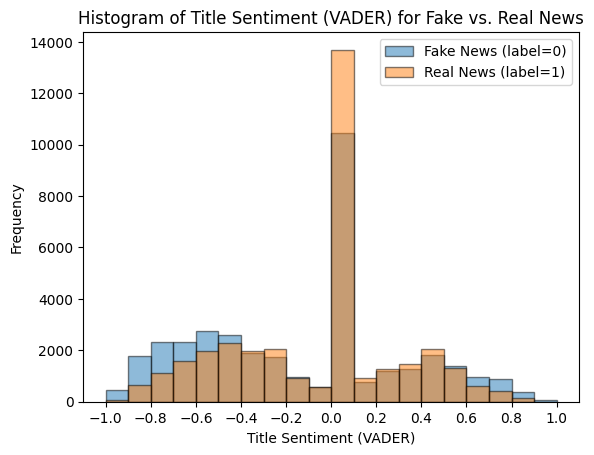

In [ ]:
#Histogram that compares distribution of fake vs real news for the sentient values of their titles

fake_news = cleaned_df[cleaned_df["label"] == 0]["title_sentiment_vader"]
real_news = cleaned_df[cleaned_df["label"] == 1]["title_sentiment_vader"]

bins = np.arange(-1, 1.1, 0.1)

plt.hist(fake_news, bins=bins, alpha=0.5, label="Fake News (label=0)", edgecolor='black')
plt.hist(real_news, bins=bins, alpha=0.5, label="Real News (label=1)", edgecolor='black')

plt.xlabel("Title Sentiment (VADER)")
plt.ylabel("Frequency")
plt.title("Histogram of Title Sentiment (VADER) for Fake vs. Real News")
plt.xticks(np.arange(-1, 1.1, 0.2))  # Adjusting tick marks for clarity
plt.legend()

plt.show()

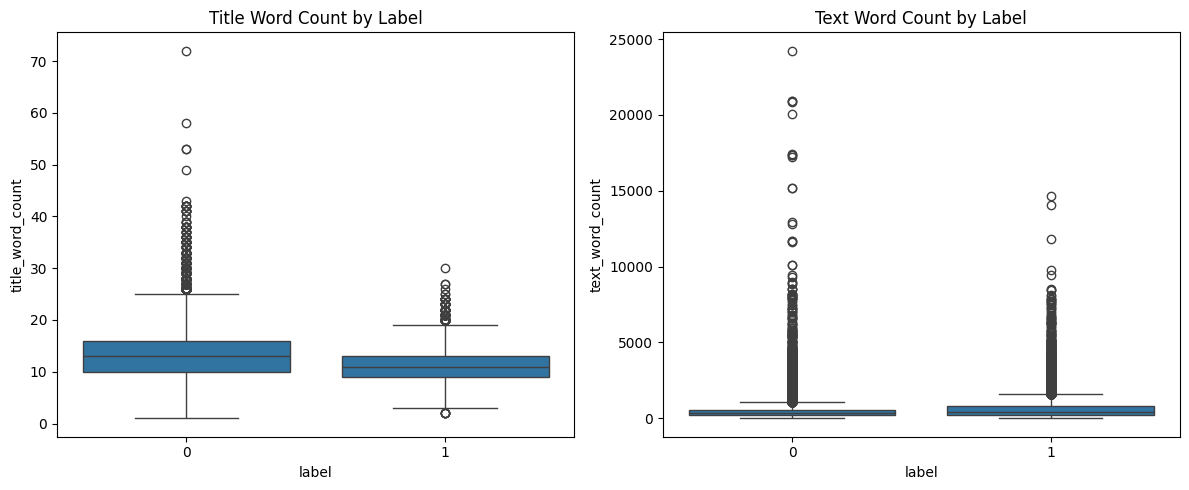

In [ ]:
# Comparison of title and text word count between fake and real news

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='label', y='title_word_count', data=cleaned_df, ax=axes[0])
axes[0].set_title('Title Word Count by Label')

sns.boxplot(x='label', y='text_word_count', data=cleaned_df, ax=axes[1])
axes[1].set_title('Text Word Count by Label')

plt.tight_layout()
plt.show()

In [ ]:
fake_text = " ".join(cleaned_df[cleaned_df["label"] == 0]["clean_text"])
real_text = " ".join(cleaned_df[cleaned_df["label"] == 1]["clean_text"])

In [ ]:
fake_word_counts = Counter(fake_text.split())
real_word_counts = Counter(real_text.split())

# Top 20 most common words
print("Top 20 Words in Fake News:")
print(fake_word_counts.most_common(100))

print("\nTop 20 Words in Real News:")
print(real_word_counts.most_common(100))

Top 20 Words in Fake News:
[('s', 129748), ('trump', 102672), ('say', 65022), ('people', 48389), ('clinton', 46138), ('t', 41246), ('president', 38782), ('state', 34526), ('year', 33911), ('like', 32764), ('time', 31961), ('hillary', 30983), ('know', 29932), ('go', 29404), ('new', 28368), ('obama', 27999), ('right', 24454), ('donald', 24446), ('come', 24327), ('election', 22822), ('tell', 22475), ('think', 21512), ('government', 21352), ('news', 21283), ('country', 21023), ('report', 20900), ('american', 20809), ('want', 20501), ('white', 20120), ('campaign', 19979), ('work', 19865), ('world', 19475), ('day', 19384), ('medium', 18655), ('take', 18458), ('way', 17984), ('vote', 17970), ('america', 17789), ('woman', 17215), ('call', 16672), ('war', 16657), ('man', 16480), ('need', 16318), ('u.s', 16317), ('house', 16163), ('good', 16000), ('thing', 15965), ('image', 15921), ('$', 15848), ('support', 15245), ('law', 15234), ('get', 15228), ('email', 14762), ('look', 14571), ('political', 

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(cleaned_df["clean_text"])
y = df["label"]

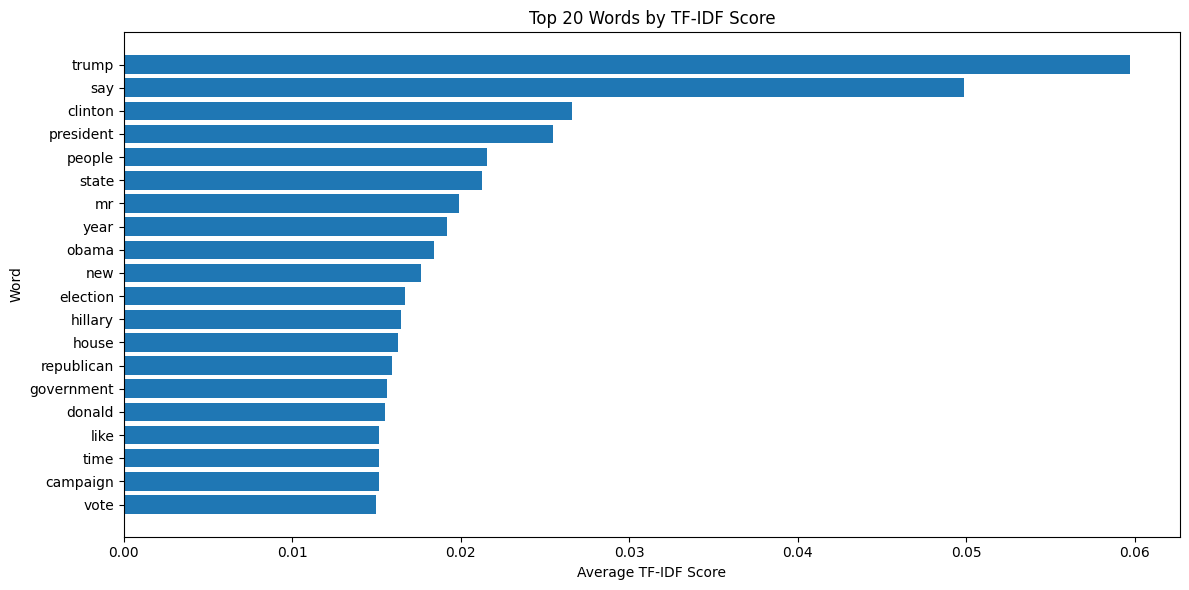

In [ ]:
tfidf_means = np.asarray(X.mean(axis=0)).flatten()
word_scores = pd.DataFrame({"word": vectorizer.get_feature_names_out(), "avg_tfidf": tfidf_means})

# Top 20 words for TF-IDF scores
top_words = word_scores.sort_values(by="avg_tfidf", ascending=False).head(20)

plt.figure(figsize=(12, 6))
plt.barh(top_words["word"][::-1], top_words["avg_tfidf"][::-1])
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word")
plt.title("Top 20 Words by TF-IDF Score")
plt.tight_layout()
plt.show()

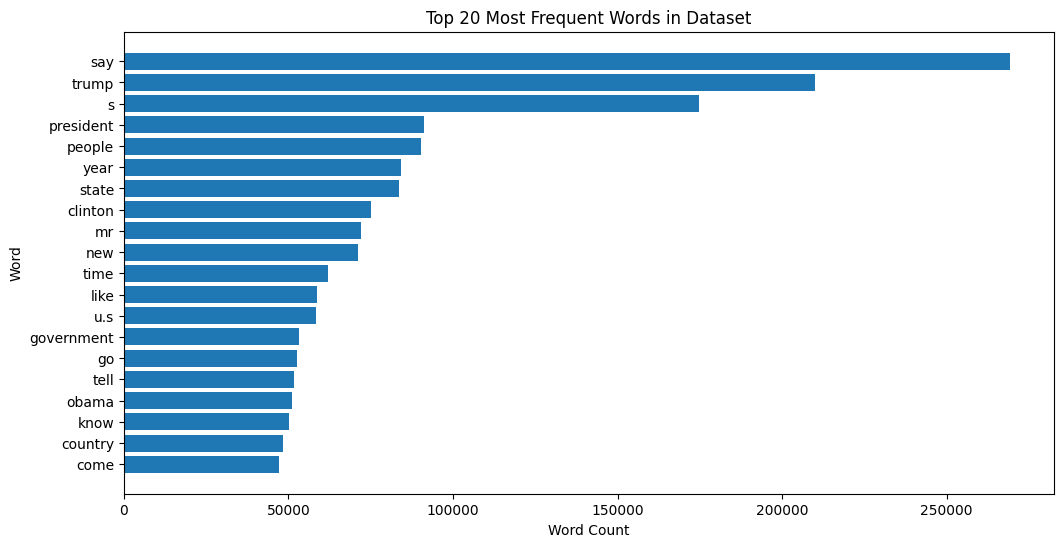

In [ ]:
#Top 20 most frequent words in dataset

all_words = " ".join(cleaned_df["clean_text"]).split()
word_counts = Counter(all_words)

top_words_freq = word_counts.most_common(20)
words, counts = zip(*top_words_freq)

plt.figure(figsize=(12, 6))
plt.barh(words[::-1], counts[::-1])
plt.xlabel("Word Count")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words in Dataset")
plt.show()

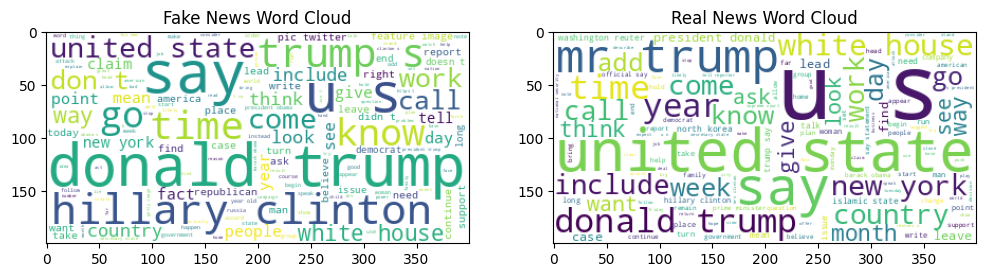

In [ ]:
# Word Cloud - this cell takes ~2 minutes to run.

fake_text = " ".join(cleaned_df[cleaned_df["label"] == 0]["clean_text"])
real_text = " ".join(cleaned_df[cleaned_df["label"] == 1]["clean_text"])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(background_color="white").generate(fake_text))
plt.title("Fake News Word Cloud")

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(background_color="white").generate(real_text))
plt.title("Real News Word Cloud")

plt.show()

## Type 1 Models

In [ ]:
#Model type only looking at variables  created in EDA for Logistic Regression, LDA, QDA, Naive Bayes


predictors = ["title_word_count", "text_word_count", "title_all_caps_count",
              "has_exclamation", "has_question", "title_sentiment_vader", "text_sentiment_textblob"]
target = "label"

# Drop rows with missing values
cleaned_df = cleaned_df.dropna(subset=predictors + [target])

X = cleaned_df[predictors]
y = cleaned_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LDA(),
    "QDA": QDA(),
    "Naïve Bayes": GaussianNB()
}

results = {}

#Evaluates accuracy and test error

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    test_error = 1 - accuracy

    results[model_name] = {"Accuracy": accuracy, "Test Error": test_error}

print(results)

{'Logistic Regression': {'Accuracy': 0.7337943559653535, 'Test Error': 0.2662056440346465}, 'LDA': {'Accuracy': 0.7419670298966191, 'Test Error': 0.2580329701033809}, 'QDA': {'Accuracy': 0.7136071528359877, 'Test Error': 0.28639284716401225}, 'Naïve Bayes': {'Accuracy': 0.7153534506845488, 'Test Error': 0.2846465493154512}}


In [ ]:
# Monte Carlo Cross Validation on Model 1 evaluating the following metrics
# ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']



predictors = ["title_word_count", "text_word_count", "title_all_caps_count",
              "has_exclamation", "has_question", "title_sentiment_vader", "text_sentiment_textblob"]
target = "label"

cleaned_df = cleaned_df.dropna(subset=predictors + [target])

X = cleaned_df[predictors]
y = cleaned_df[target]

monte_carlo_cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LDA(),
    "QDA": QDA(),
    "Naïve Bayes": GaussianNB()
}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = {}

for model_name, model in models.items():
    scores = cross_validate(model, X, y, cv=monte_carlo_cv, scoring=scoring_metrics, return_train_score=False)

    results[model_name] = {
        "Accuracy": np.mean(scores['test_accuracy']),
        "Test Error": 1 - np.mean(scores['test_accuracy']),
        "Precision": np.mean(scores['test_precision']),
        "Recall": np.mean(scores['test_recall']),
        "F1 Score": np.mean(scores['test_f1']),
        "AUC-ROC": np.mean(scores['test_roc_auc'])
    }

results_df = pd.DataFrame(results).T.round(4)

In [ ]:
print(results_df)

                     Accuracy  Test Error  Precision  Recall  F1 Score  \
Logistic Regression    0.7351      0.2649     0.6935  0.8219    0.7522   
LDA                    0.7414      0.2586     0.6711  0.9249    0.7778   
QDA                    0.7193      0.2807     0.6442  0.9524    0.7685   
Naïve Bayes            0.7201      0.2799     0.6448  0.9527    0.7691   

                     AUC-ROC  
Logistic Regression   0.7825  
LDA                   0.7809  
QDA                   0.8158  
Naïve Bayes           0.8061  


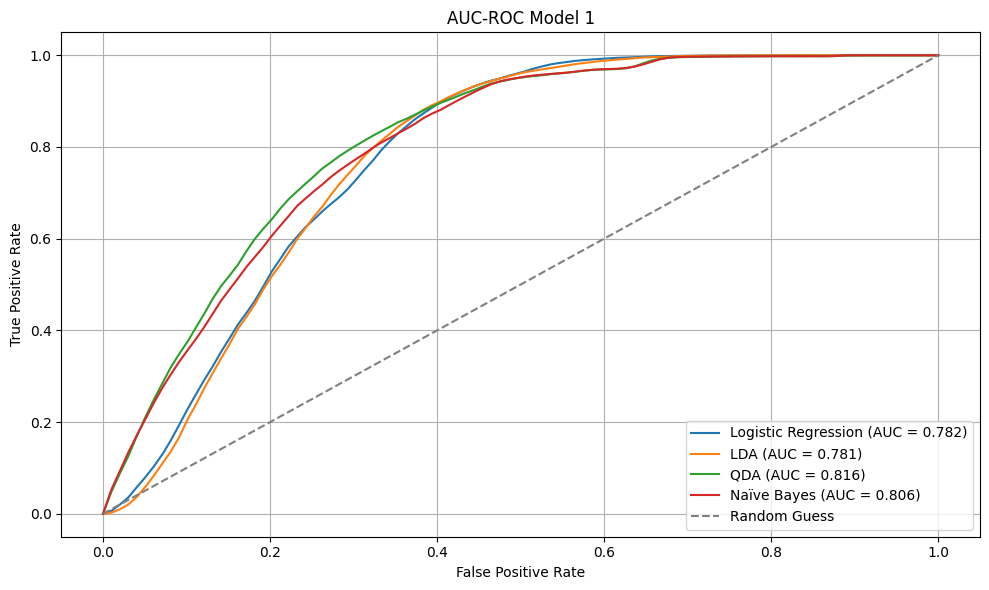

In [ ]:

plt.figure(figsize=(10, 6))

for model_name, model in models.items():
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in monte_carlo_cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)[:, 1]
        else:
            # Some models (like LDA) may not have predict_proba depending on sklearn version
            y_probs = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_probs)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    plt.plot(mean_fpr, mean_tpr, label=f"{model_name} (AUC = {mean_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Model 1")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Type 2 Models

In [ ]:
# Evaluate models that look at both TF-IDF values for the text column in addition to predictor variables
# from type 1 model

# Apply TF-IDF to the text columns
text_column = "clean_text"

tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# Transform text data into numerical values
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_df[text_column])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Combine TF-IDF features with predictors from type 1 models
combined_df = pd.concat([cleaned_df.reset_index(drop=True), tfidf_df], axis=1)

In [ ]:
# Drop fields that are not numerical - this cell takes ~8-10 min to run.
excluded_vars = ["title", "text", "clean_text", "title_all_caps_binned", "title_sentiment_category"]
combined_df = combined_df.drop(columns=excluded_vars, errors="ignore")

predictors = [col for col in combined_df.columns if col != "label"]
target = "label"

combined_df = combined_df.dropna(subset=predictors + [target])

X = combined_df[predictors]
y = combined_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "LDA": LDA(),
    "QDA": QDA(),
    "Naïve Bayes": GaussianNB()
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)  #
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    test_error = 1 - accuracy

    results[model_name] = {"Accuracy": accuracy, "Test Error": test_error}

print(results)

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


{'Logistic Regression': {'Accuracy': 0.953059513830679, 'Test Error': 0.046940486169321005}, 'LDA': {'Accuracy': 0.9453059513830679, 'Test Error': 0.054694048616932056}, 'QDA': {'Accuracy': 0.8722408493992735, 'Test Error': 0.1277591506007265}, 'Naïve Bayes': {'Accuracy': 0.831377479742945, 'Test Error': 0.16862252025705504}}


In [ ]:
# Cross Validation on Type 2 Models - this cell takes a long time to run, ~ 33 min.
excluded_vars = ["title", "text", "clean_text", "title_all_caps_binned", "title_sentiment_category"]
combined_df = combined_df.drop(columns=excluded_vars, errors="ignore")

predictors = [col for col in combined_df.columns if col != "label"]
target = "label"

combined_df = combined_df.dropna(subset=predictors + [target])
X = combined_df[predictors]
y = combined_df[target]

monte_carlo_cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "LDA": LDA(),
    "QDA": QDA(),
    "Naïve Bayes": GaussianNB()
}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = {}

for model_name, model in models.items():
    scores = cross_validate(model, X, y, cv=monte_carlo_cv, scoring=scoring_metrics)

    results[model_name] = {
        "Accuracy": np.mean(scores['test_accuracy']),
        "Test Error": 1 - np.mean(scores['test_accuracy']),
        "Precision": np.mean(scores['test_precision']),
        "Recall": np.mean(scores['test_recall']),
        "F1 Score": np.mean(scores['test_f1']),
        "AUC-ROC": np.mean(scores['test_roc_auc'])
    }

results_df = pd.DataFrame(results).T.round(4)

print(results_df)

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

                     Accuracy  Test Error  Precision  Recall  F1 Score  \
Logistic Regression    0.9547      0.0453     0.9542  0.9531    0.9536   
LDA                    0.9483      0.0517     0.9512  0.9428    0.9469   
QDA                    0.8783      0.1217     0.8922  0.8546    0.8730   
Naïve Bayes            0.8360      0.1640     0.8263  0.8418    0.8340   

                     AUC-ROC  
Logistic Regression   0.9910  
LDA                   0.9885  
QDA                   0.9515  
Naïve Bayes           0.8980  


/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

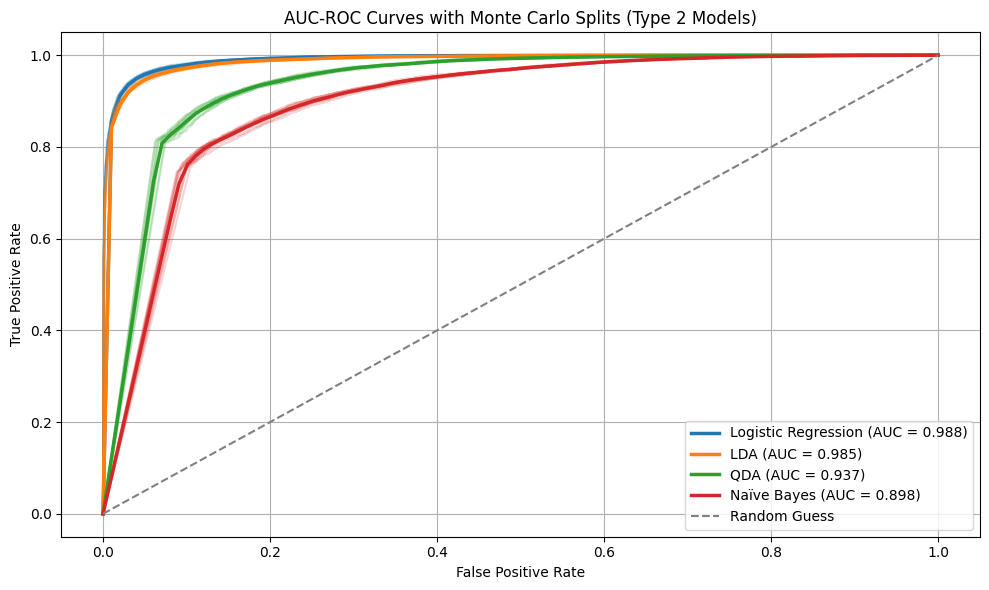

In [ ]:
# This cell takes a long time to run, ~ 60 min.
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10.colors
model_names = list(models.keys())

for idx, (model_name, model) in enumerate(models.items()):
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)
    color = colors[idx % len(colors)]

    for train_idx, test_idx in monte_carlo_cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)[:, 1]
        else:
            y_probs = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_probs)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)


        plt.plot(fpr, tpr, color=color, alpha=0.2)


    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, color=color, linewidth=2.5, label=f"{model_name} (AUC = {mean_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curves with Monte Carlo Splits (Type 2 Models)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Type 3 Models

In [ ]:
# Use only the TF-IDF features and labels
X_tfidf = tfidf_matrix
y_tfidf = cleaned_df["label"]

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y_tfidf, test_size=0.2, random_state=42
)

models_tfidf = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LDA(),
    "QDA": QDA(),
    "Naïve Bayes": GaussianNB()
}

results_tfidf = {}

for name, model in models_tfidf.items():
    # Converts from sparse to dense matrix to fit the models below
    if name in ["LDA", "QDA", "Naïve Bayes"]:
        X_train_input = X_train_tfidf.toarray()
        X_test_input = X_test_tfidf.toarray()
    else:
        X_train_input = X_train_tfidf
        X_test_input = X_test_tfidf

    model.fit(X_train_input, y_train_tfidf)
    y_pred = model.predict(X_test_input)

    accuracy = accuracy_score(y_test_tfidf, y_pred)
    test_error = 1 - accuracy

    results_tfidf[name] = {
        "Accuracy": round(accuracy, 4),
        "Test Error": round(test_error, 4)
    }

for model, scores in results_tfidf.items():
    print(f"\nModel: {model}")
    for metric, value in scores.items():
        print(f"{metric}: {value}")

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(



Model: Logistic Regression
Accuracy: 0.9392
Test Error: 0.0608

Model: LDA
Accuracy: 0.9337
Test Error: 0.0663

Model: QDA
Accuracy: 0.8576
Test Error: 0.1424

Model: Naïve Bayes
Accuracy: 0.837
Test Error: 0.163


In [ ]:
print(results_tfidf)

{'Logistic Regression': {'Accuracy': 0.9392, 'Test Error': 0.0608}, 'LDA': {'Accuracy': 0.9337, 'Test Error': 0.0663}, 'QDA': {'Accuracy': 0.8576, 'Test Error': 0.1424}, 'Naïve Bayes': {'Accuracy': 0.837, 'Test Error': 0.163}}


In [ ]:
# This cell takes ~10 minutes to run.

X = tfidf_matrix.toarray()  # Converts sparse to dense input for all models
y = cleaned_df["label"].values

monte_carlo_cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LDA(),
    "QDA": QDA(),
    "Naïve Bayes": GaussianNB()
}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = {}

for model_name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=monte_carlo_cv, scoring=scoring_metrics, return_train_score=False
    )

    results[model_name] = {
        "Accuracy": np.mean(scores['test_accuracy']),
        "Test Error": 1 - np.mean(scores['test_accuracy']),
        "Precision": np.mean(scores['test_precision']),
        "Recall": np.mean(scores['test_recall']),
        "F1 Score": np.mean(scores['test_f1']),
        "AUC-ROC": np.mean(scores['test_roc_auc'])
    }

results_df = pd.DataFrame(results).T.round(4)
print(results_df)

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

                     Accuracy  Test Error  Precision  Recall  F1 Score  \
Logistic Regression    0.9423      0.0577     0.9454  0.9362    0.9407   
LDA                    0.9373      0.0627     0.9451  0.9256    0.9352   
QDA                    0.8634      0.1366     0.8666  0.8520    0.8593   
Naïve Bayes            0.8423      0.1577     0.8427  0.8331    0.8379   

                     AUC-ROC  
Logistic Regression   0.9862  
LDA                   0.9837  
QDA                   0.9429  
Naïve Bayes           0.9072  


/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

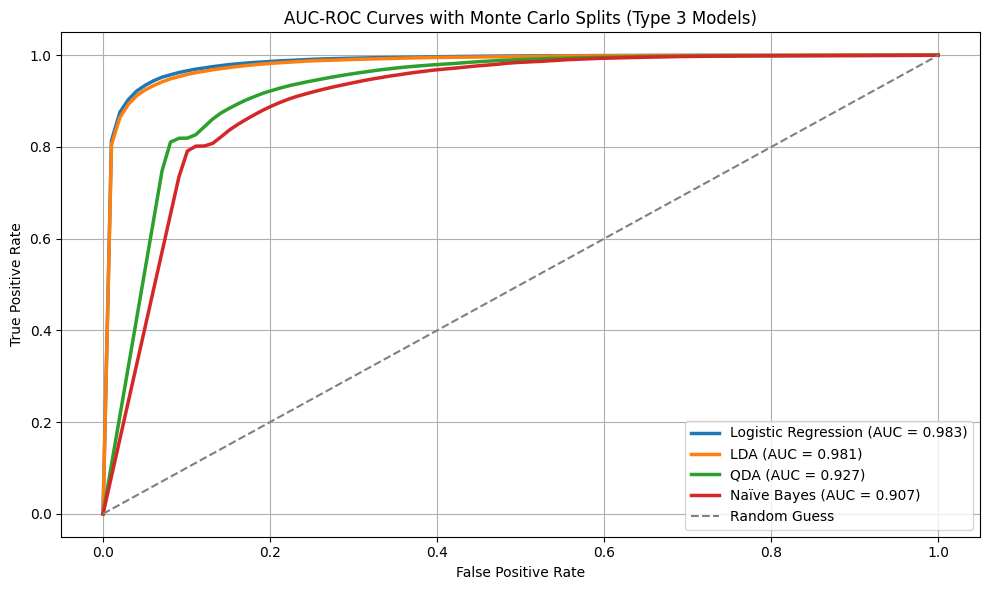

In [ ]:
# This cell takes ~10 minutes to run.
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10.colors
model_names = list(models.keys())

for idx, (model_name, model) in enumerate(models.items()):
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)
    color = colors[idx % len(colors)]

    for train_idx, test_idx in monte_carlo_cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)[:, 1]
        else:
            y_probs = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_probs)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)


    # Mean ROC curve
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, label=f"{model_name} (AUC = {mean_auc:.3f})", color=color, linewidth=2.5)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curves with Monte Carlo Splits (Type 3 Models)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Type 4 Models Stacking

In [ ]:
#Use stacking ensemble method to improve upon models

X = cleaned_df["clean_text"]
y = cleaned_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Base Models for stacking
base_learners = [
    ('lr', LogisticRegression(max_iter=500, solver="saga")),  # Faster solver
    ('nb', MultinomialNB())  # Naïve Bayes (FAST alternative to LDA). In addition MultinomialNB
    #works better with cout data while GaussianNB works better for continuous data
]

# Meta-Mode; as Logistic Regression
meta_model = LogisticRegression(max_iter=500, solver="saga")

# Use Stacking Model
clf_stack = StackingClassifier(estimators=base_learners, final_estimator=meta_model, passthrough=True)

model_stack = clf_stack.fit(X_train_tfidf, y_train)

pred_stack = model_stack.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, pred_stack)
test_error = 1 - accuracy

print(test_error)

0.04121262922604074


In [ ]:
# This cell takes ~8 minutes to run.

X = cleaned_df["clean_text"]
y = cleaned_df["label"].values

# Base Learners and Meta Learner
base_learners = [
    ('lr', LogisticRegression(max_iter=500, solver="saga")),
    ('nb', MultinomialNB())
]
meta_model = LogisticRegression(max_iter=500, solver="saga")

# Stacking Classifier
stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    passthrough=True
)

# Pipeline TF-IDF + Stacking
pipe = make_pipeline(
    TfidfVectorizer(max_features=5000),
    stack_clf
)

monte_carlo_cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    pipe, X, y,
    cv=monte_carlo_cv,
    scoring=scoring_metrics,
    return_train_score=False,
    n_jobs=-1
)

stacking_summary = {
    "Accuracy": np.mean(cv_results['test_accuracy']),
    "Test Error": 1 - np.mean(cv_results['test_accuracy']),
    "Precision": np.mean(cv_results['test_precision']),
    "Recall": np.mean(cv_results['test_recall']),
    "F1 Score": np.mean(cv_results['test_f1']),
    "AUC-ROC": np.mean(cv_results['test_roc_auc'])
}

stacking_df = pd.DataFrame([stacking_summary], index=["Stacking Model"]).round(4)
print(stacking_df)

                Accuracy  Test Error  Precision  Recall  F1 Score  AUC-ROC
Stacking Model    0.9609      0.0391     0.9628  0.9571      0.96   0.9933


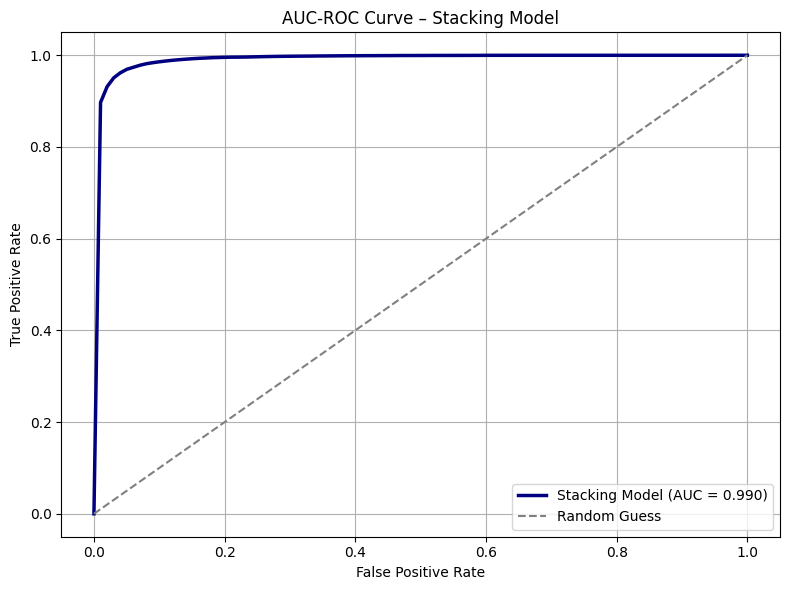

In [ ]:
# This cell takes ~9 minutes to run.
# Create placeholders to collect TPRs
tprs = []
mean_fpr = np.linspace(0, 1, 100)

# Loop over each Monte Carlo split
for train_idx, test_idx in monte_carlo_cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit the TF-IDF + Stacking pipeline
    pipe.fit(X_train, y_train)

    # Get predicted probabilities from the final classifier
    y_probs = pipe.predict_proba(X_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)

    # Interpolate for consistent averaging
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Calculate mean TPR and AUC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr, label=f"Stacking Model (AUC = {mean_auc:.3f})", color='navy', linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve – Stacking Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()